First 5 Rows of Iris Dataset:
   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa

Features and their Data Types:
sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety          object
dtype: object


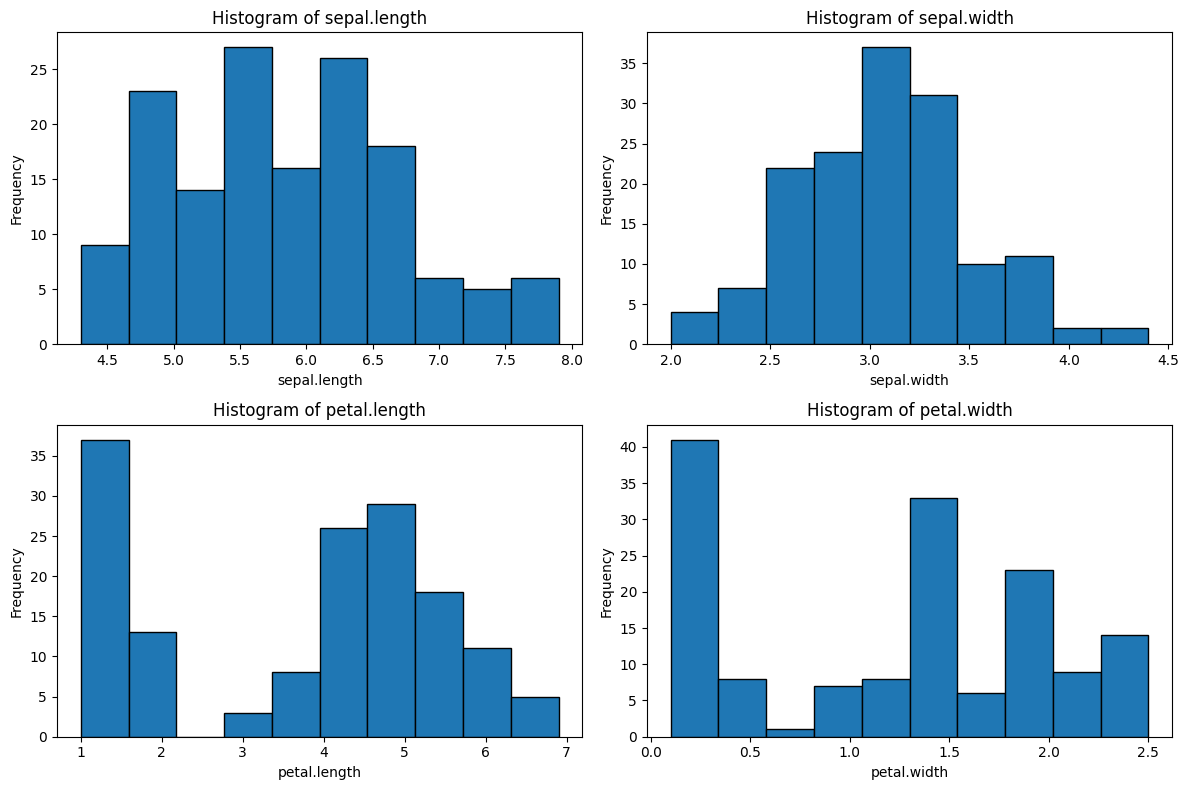

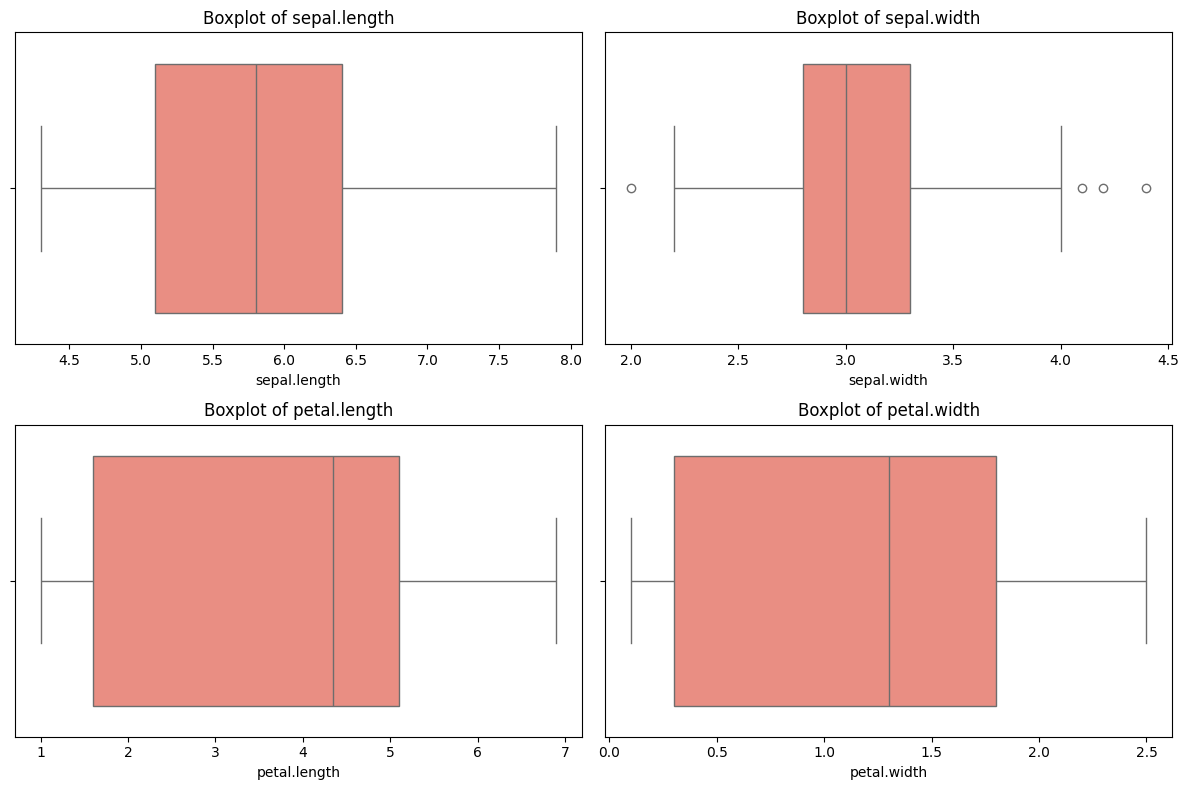


Outlier Detection and Distribution Comparison:

Feature: sepal.length
Mean: 5.84
Median: 5.80
Standard Deviation: 0.83
Outliers Detected: No

Feature: sepal.width
Mean: 3.06
Median: 3.00
Standard Deviation: 0.44
Outliers Detected: Yes
Outlier Values: [4.4, 4.1, 4.2, 2.0]

Feature: petal.length
Mean: 3.76
Median: 4.35
Standard Deviation: 1.77
Outliers Detected: No

Feature: petal.width
Mean: 1.20
Median: 1.30
Standard Deviation: 0.76
Outliers Detected: No


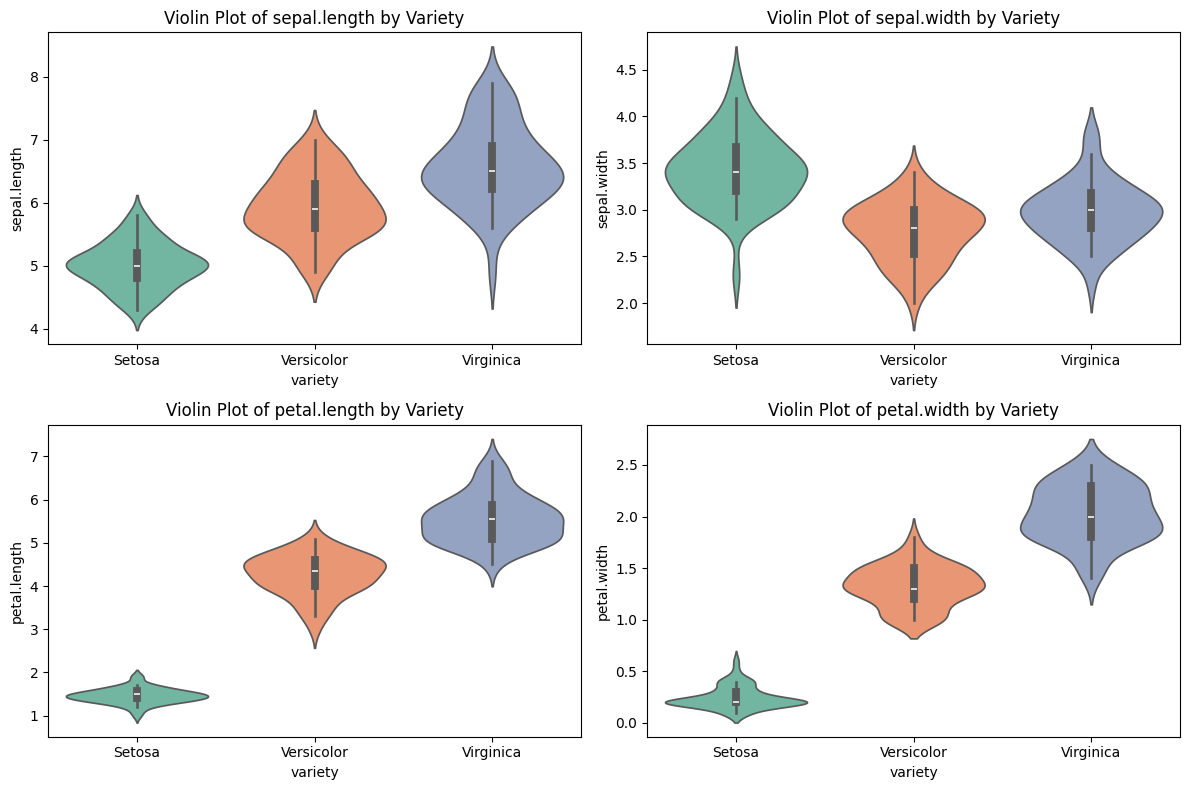

In [3]:
# DSBDA Practical 10: Data Visualization III - Iris Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Iris.csv")

print("First 5 Rows of Iris Dataset:")
print(df.head())

# 1. List features and their types
print("\nFeatures and their Data Types:")
print(df.dtypes)

# 2. Histogram for each numerical feature
plt.figure(figsize=(12, 8))
for i, column in enumerate(df.columns[:-1]):   # Exclude target column 'variety'
    plt.subplot(2, 2, i + 1)
    plt.hist(df[column], bins=10, edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# 3. Boxplot for each numerical feature
plt.figure(figsize=(12, 8))
for i, column in enumerate(df.columns[:-1]):   # Exclude target column 'variety'
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[column], color='salmon')
    plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

# 4. Compare distributions and identify outliers
print("\nOutlier Detection and Distribution Comparison:")
for column in df.columns[:-1]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]

    print(f"\nFeature: {column}")
    print(f"Mean: {df[column].mean():.2f}")
    print(f"Median: {df[column].median():.2f}")
    print(f"Standard Deviation: {df[column].std():.2f}")
    print(f"Outliers Detected: {'Yes' if not outliers.empty else 'No'}")
    if not outliers.empty:
        print(f"Outlier Values: {outliers.tolist()}")

# Violin plot for comparison
plt.figure(figsize=(12, 8))
for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2, 2, i + 1)
    sns.violinplot(x='variety', y=column, hue='variety', data=df, palette='Set2', legend=False)
    plt.title(f"Violin Plot of {column} by Variety")

plt.tight_layout()
plt.show()